Text(0, 0.5, 'I [A]')

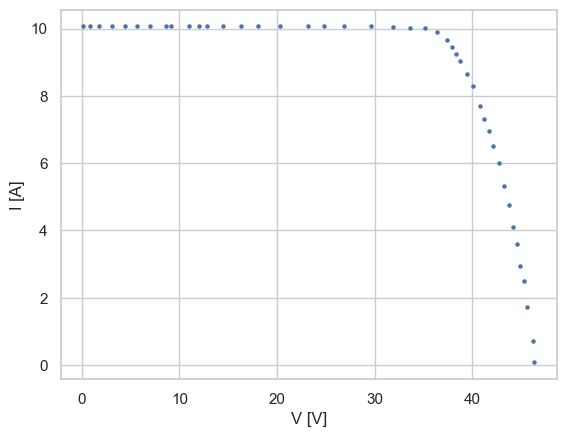

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
import seaborn as sns
from scipy.signal import argrelmin
# data means from data sheet

data = np.loadtxt('IV_Curve_1000wpm2_5c.csv', delimiter = ',')
# print(data)

voltage_data = data[:,0]
current_data = data[:,1]
plt.scatter(voltage_data,current_data, s = 5)
plt.xlabel('V [V]')
plt.ylabel('I [A]')

In [88]:
# import panel data function
def Import_Panel_Data(year, day):
    
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"../DataFolder/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    file_103 = pd.read_csv(f"../DataFolder/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    date = file_103['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep = NumberDate <= int(input_2)
    file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    time_103 = file_103['Time']
    voltage_103 = file_103['V'] 
    current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    power_103 = voltage_103 * current_103
    # -----------------------------

    # print(f'len(power_101) = {len(power_101)}')
    return voltage_101.to_numpy(), voltage_103.to_numpy(), current_101.to_numpy(), current_103.to_numpy(), power_101.to_numpy(), power_103.to_numpy(), time_101.to_numpy(), time_103.to_numpy()






    

Text(0, 0.5, 'I [A]')

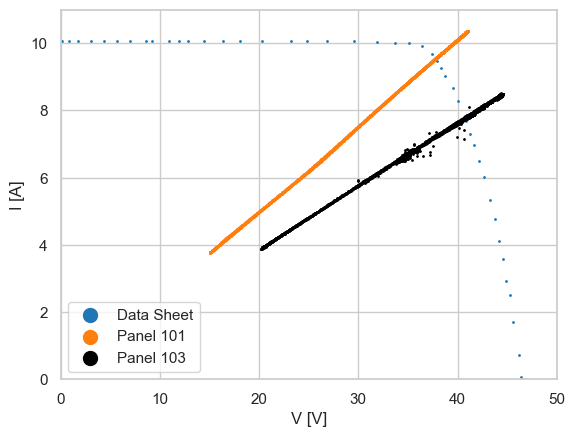

In [89]:


voltage_101, voltage_103, current_101, current_103, power_101, power_103, time_101, time_103 = Import_Panel_Data(25,345)

voltage_data = data[:,0]
current_data = data[:,1]
plt.scatter(voltage_data,current_data, s = 1, color = 'tab:blue', label = 'Data Sheet')
plt.scatter(voltage_101,current_101, s = 1, color = 'tab:orange', label = 'Panel 101')
plt.scatter(voltage_103,current_103, s = 1, color = 'black', label = 'Panel 103')
plt.legend(markerscale = 10)
plt.xlim(0,50)
plt.ylim(0,11)
plt.xlabel('V [V]')
plt.ylabel('I [A]')





[ 0.25554386 -0.12081156]


Text(0.5, 1.0, 'IV and Power curve for Panel 101\n1000 $\\frac{W}{m^2}$ 5°c')

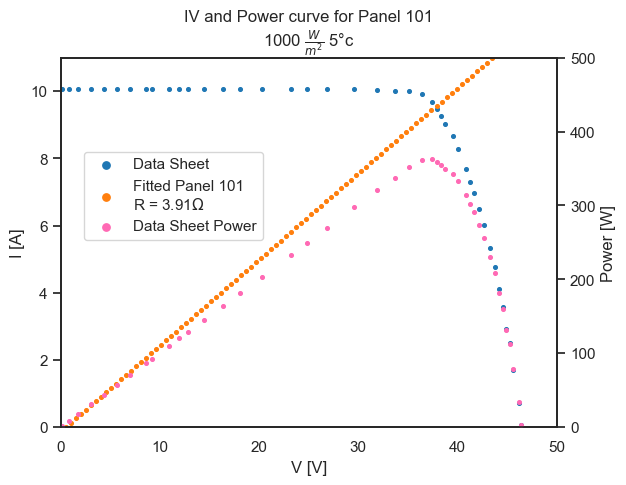

In [96]:
# Lets fit a horizontal line to the data sheet and lines to the panels


# print(voltage_103)
# print(current_103)
# lets mask the nan values
# mask = np.isnan(voltage_103)&np.isnan(current_103)

panel_101_coeffs = np.polyfit(voltage_101, current_101, deg = 1)
# panel_103_coeffs = np.polyfit(voltage_103, current_103, deg = 1)

print(panel_101_coeffs)
# print(panel_103_coeffs)


m_101 = panel_101_coeffs[0]
b_101 = panel_101_coeffs[1]

fit_voltage_101 = np.linspace(0,50,100)
fit_current_101 = m_101*fit_voltage_101 + b_101
fig, ax = plt.subplots()

# find the power based on data
power_data = voltage_data*current_data


ax1 = ax.twinx()
ax1.scatter(voltage_data, power_data, s = 7, color = 'hotpink', label = 'Data Sheet Power')
ax1.set_ylim(0,500)
ax.scatter(voltage_data,current_data, s = 7, color = 'tab:blue', label = 'Data Sheet')
ax.scatter(fit_voltage_101,fit_current_101, s = 7, color = 'tab:orange', label = f'Fitted Panel 101\nR = {np.round(1/m_101,2)}$\\Omega$')
# plt.scatter(voltage_103,current_103, s = 1, color = 'black', label = 'Panel 103')
# ax.legend(markerscale = 10)
ax.set_xlim(0,50)
ax.set_ylim(0,11)
ax.set_xlabel('V [V]')
ax.set_ylabel('I [A]')
ax1.set_ylabel('Power [W]')
fig.legend(loc='upper left', bbox_to_anchor=(.15, .7), markerscale = 2)
sns.set_theme(style='white')
plt.grid(False)
ax.set_title(r'IV and Power curve for Panel 101'+'\n'+r'1000 $\frac{W}{m^2}$ 5°c')

# ax.show()

